In [2]:
import pyspark
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

In [23]:
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.types import StructField, StructType, StringType, LongType, IntegerType, FloatType
from pyspark.sql.functions import hour, to_timestamp
import pyspark.sql.functions as F
from pyspark.sql.types import *
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler, IndexToString
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, RegressionEvaluator

In [4]:
ss=SparkSession.builder.appName("severity_prediction").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 12:23:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
data = ss.read.csv("/work/jhp5351/DS410_F25/project/crashcrew/US_Accidents_March23.csv", header=True, inferSchema=False)

In [6]:
data.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: string (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- End_Time: string (nullable = true)
 |-- Start_Lat: string (nullable = true)
 |-- Start_Lng: string (nullable = true)
 |-- End_Lat: string (nullable = true)
 |-- End_Lng: string (nullable = true)
 |-- Distance(mi): string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: string (nullable = true)
 |-- Temperature(F): string (nullable = true)
 |-- Wind_Chill(F): string (nullable = true)
 |-- Humidity(%): string (nullable = true)
 |-- Pressure(in): string (nullable = true)
 |-- Visibility(

In [7]:
data = data.dropna()

In [8]:
data.show(5)

25/12/02 12:23:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------+-------+--------+-------------------+-------------------+-----------------+----------+--------+------------------+------------+--------------------+--------------------+--------+---------+-----+-------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-------------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|       ID| Source|Severity|         Start_Time|           End_Time|        Start_Lat| Start_Lng| End_Lat|           End_Lng|Distance(mi)|         Description|              Street|    City|   County|State|Zipcode|Country|  Timezone|Airport_Code|  Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|  Weather_Conditi

In [9]:
cols = ["ID", "Start_Time", "Severity", "State"]
data = data.select(*cols)

In [10]:
data = data.withColumn("Hours", hour("Start_Time"))

In [11]:
data.show(5)

+---------+-------------------+--------+-----+-----+
|       ID|         Start_Time|Severity|State|Hours|
+---------+-------------------+--------+-----+-----+
|A-3447191|2016-12-06 14:28:06|       2|   OH|   14|
|A-3420085|2016-04-27 03:50:41|       2|   CA|    3|
|A-3456576|2017-01-05 16:33:16|       3|   IL|   16|
|A-3458082|2017-01-10 15:48:54|       2|   NY|   15|
|A-3459593|2017-01-16 06:48:42|       2|   IL|    6|
+---------+-------------------+--------+-----+-----+
only showing top 5 rows


In [14]:
data_with_counts = (
    data.groupBy("Hours", "Severity")
    .agg(F.count("*").alias("Accident Count"))
    .orderBy("Hours", "Severity", "Accident Count")
)

data_with_counts.show(10)

+-----+--------+--------------+
|Hours|Severity|Accident Count|
+-----+--------+--------------+
|    0|       1|             1|
|    0|       2|           816|
|    0|       3|            14|
|    0|       4|            54|
|    1|       1|             2|
|    1|       2|           651|
|    1|       3|             5|
|    1|       4|            24|
|    2|       1|             3|
|    2|       2|           654|
+-----+--------+--------------+
only showing top 10 rows


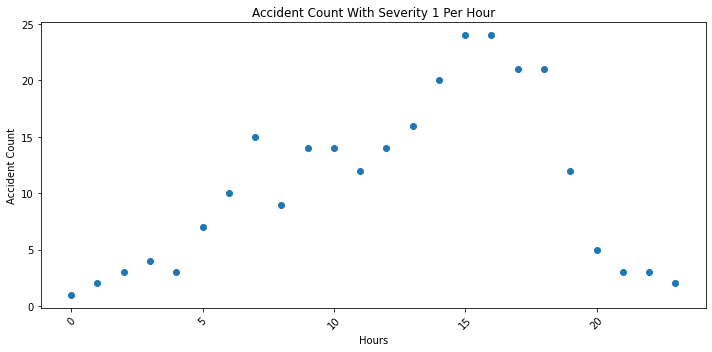

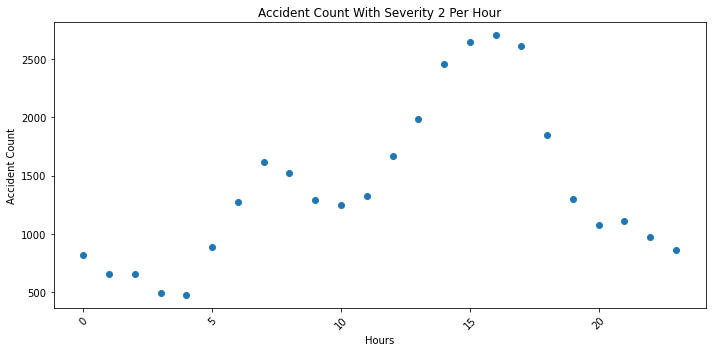

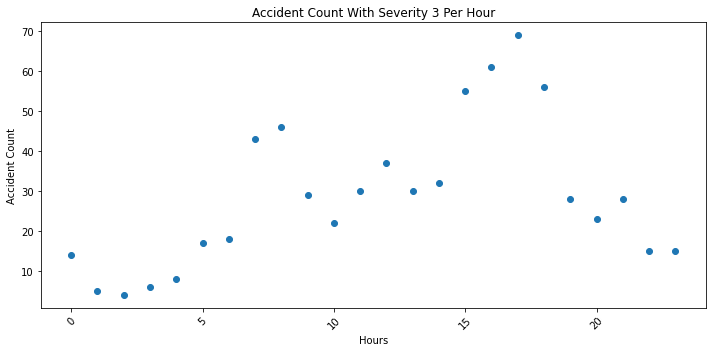

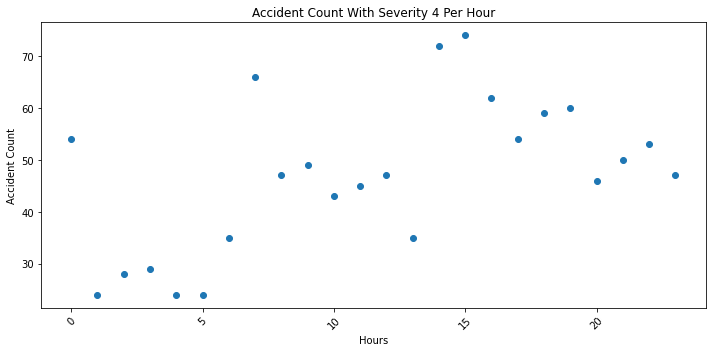

In [15]:
# Loop through severity level to output plot based on each severity
for i in range(1, 5):
    data_per_severity = data_with_counts.filter(data_with_counts["Severity"] == i).orderBy("Hours").collect()

    # Convert to numpy arrays
    times = np.array([r["Hours"] for r in data_per_severity])
    severities = np.array([r["Accident Count"] for r in data_per_severity], dtype=float)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.scatter(times, severities)
    plt.title(f"Accident Count With Severity {i} Per Hour")
    plt.xlabel("Hours")
    plt.ylabel("Accident Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [17]:
counts_per_hour = (
    data_with_counts
    .groupBy("Hours")
    .agg(F.sum("Accident Count").alias("Accident Count"))
    .orderBy("Hours")
)

counts_per_hour.show()

+-----+--------------+
|Hours|Accident Count|
+-----+--------------+
|    0|           885|
|    1|           682|
|    2|           689|
|    3|           533|
|    4|           511|
|    5|           937|
|    6|          1340|
|    7|          1742|
|    8|          1622|
|    9|          1384|
|   10|          1329|
|   11|          1416|
|   12|          1767|
|   13|          2069|
|   14|          2582|
|   15|          2803|
|   16|          2853|
|   17|          2755|
|   18|          1988|
|   19|          1395|
+-----+--------------+
only showing top 20 rows


In [28]:
train_df, valid_df= counts_per_hour.randomSplit([0.8, 0.2], seed=42)
hyperparams_eval_df = pd.DataFrame(
    columns=["maxDepth", "minInstancesPerNode", "training_rmse", "valid_rmse", "BestModel"]
)
index = 0
maxDepths = [3, 4, 5, 6]
minInstances = [2, 3]
best_rmse = float("inf")

assembler = VectorAssembler(
    inputCols=["Hours"],
    outputCol="features"
)

evaluator = RegressionEvaluator(
    labelCol="Accident Count",
    predictionCol="prediction",
    metricName="rmse"
)

best_model = None

for depth in maxDepths:
    for ins in minInstances:
        dt = DecisionTreeRegressor(
            labelCol="Accident Count",
            featuresCol="features",
            maxDepth=depth,
            minInstancesPerNode=ins
        )
        pipeline = Pipeline(stages=[assembler, dt])
        model = pipeline.fit(train_df)

        training_predictions = model.transform(train_df)
        valid_predictions = model.transform(valid_df)

        training_rmse = evaluator.evaluate(training_predictions)
        valid_rmse = evaluator.evaluate(valid_predictions)

        hyperparams_eval_df.loc[index] = [depth, ins, training_rmse, valid_rmse, 0]
        index += 1
        if valid_rmse < best_rmse:
            best_rmse = valid_rmse
            best_max_depth = depth
            best_min_ins = ins
            best_index = index - 1
            best_model = model

print(
    "Best maxDepth =", best_max_depth,
    ", best minInstancesPerNode =", best_min_ins,
    ", validation RMSE =", best_rmse
)



25/12/02 13:03:37 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)
25/12/02 13:03:40 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)
25/12/02 13:03:43 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)
25/12/02 13:03:46 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)
25/12/02 13:03:48 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)
25/12/02 13:03:51 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)
25/12/02 13:03:54 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)
25/12/02 13:03:57 WARN DecisionTreeMetadata: DecisionTree reducing maxBins from 32 to 18 (= number of training instances)


Best maxDepth = 4 , best minInstancesPerNode = 2 , validation RMSE = 534.0835825487881


In [31]:
trained_df = best_model.transform(counts_per_hour)

trained_df.select("Hours", "Accident Count", "prediction").orderBy("Hours").show()

+-----+--------------+-----------------+
|Hours|Accident Count|       prediction|
+-----+--------------+-----------------+
|    0|           885|            783.5|
|    1|           682|            783.5|
|    2|           689|            783.5|
|    3|           533|660.3333333333334|
|    4|           511|660.3333333333334|
|    5|           937|660.3333333333334|
|    6|          1340|660.3333333333334|
|    7|          1742|           1485.0|
|    8|          1622|           1485.0|
|    9|          1384|           1485.0|
|   10|          1329|           1485.0|
|   11|          1416|           1591.5|
|   12|          1767|           1591.5|
|   13|          2069|           1591.5|
|   14|          2582|           2746.0|
|   15|          2803|           2746.0|
|   16|          2853|           2746.0|
|   17|          2755|           2371.5|
|   18|          1988|           2371.5|
|   19|          1395|           2371.5|
+-----+--------------+-----------------+
only showing top

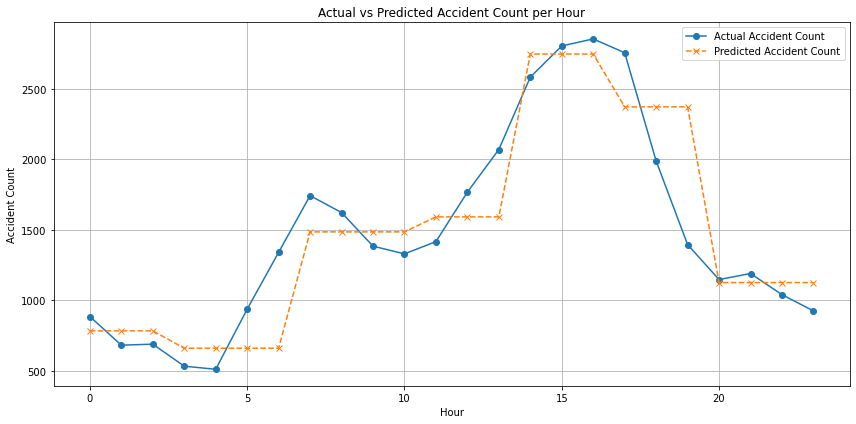

In [24]:
result = (
    trained_df
    .select("Hours", "Accident Count", "prediction")
    .orderBy("Hours")
    .toPandas()
)

# Sort just to be safe
result = result.sort_values("Hours")
result.to_csv("/storage/home/mkd5951/work/Course_project/crashcrew/accident_results.csv", index=False)
hours = result["Hours"].to_numpy()
actual = result["Accident Count"].to_numpy()
predicted = result["prediction"].to_numpy()

plt.figure(figsize=(12, 6))

plt.plot(hours, actual, marker="o", label="Actual Accident Count")
plt.plot(hours, predicted, marker="x", linestyle="--", label="Predicted Accident Count")

plt.title("Actual vs Predicted Accident Count per Hour")
plt.xlabel("Hour")
plt.ylabel("Accident Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/storage/home/mkd5951/work/Course_project/crashcrew/accident_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
ss.stop()